# Ice Lines

In this more advanced example we want to implement ice lines by changing the fragmentation velocity at a certain temperature.  
Here we simply want to have a fragmentation velocity of $10\,\mathrm{\frac{m}{s}}$ if the particles are colder than $150\,\mathrm{K}$ and covered with water ice, and a fragmentation velocity of $1\,\mathrm{\frac{m}{s}}$ otherwise.

See, however, [Musiolik & Wurm (2019)](https://doi.org/10.3847/1538-4357/ab0428) that this is most likely not a valid assumption.

For this model we initialize as DustPy simulation just as before with some default values.

In [1]:
from dustpy import Simulation

In [2]:
sim = Simulation()

In [3]:
sim.initialize()

At this points the fragmentation velocity is $100\,\mathrm{\frac{cm}{s}}$ everywhere by default.

In [4]:
sim.dust.v.frag

[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.
 100. 100.]

We now have to provide DustPy with a function to compute the fragmentation velocity depending on the gas temperature.

In [5]:
import numpy as np

In [6]:
def vfrag(sim):
    return np.where(sim.gas.T<150., 1000., 100.)

We load this function into the updater for the fragmentation velocity.

In [7]:
sim.dust.v.frag.updater = vfrag

If we now update the simulation frame...

In [8]:
sim.update()

...then the fragmentation velocity is computed with our new function.

In [9]:
sim.dust.v.frag

[ 100.  100.  100.  100.  100.  100.  100.  100.  100.  100.  100. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000.]

We can now change the name of the data directory and allow Simframe to overwrite existing files.

In [10]:
sim.writer.datadir = "3.1_ice_lines"
sim.writer.overwrite = True

We can now start our simulation.

In [11]:
sim.run()


DustPy v1.0.9

Documentation: https://stammler.github.io/dustpy/
PyPI:          https://pypi.org/project/dustpy/
GitHub:        https://github.com/stammler/dustpy/

Please cite Stammler & Birnstiel (2022).

Checking for mass conservation...

    - Sticking:
        max. rel. error:  2.81e-14
        for particle collision
            m[114] =  1.93e+04 g    with
            m[116] =  3.73e+04 g
    - Full fragmentation:
        max. rel. error:  6.66e-16
        for particle collision
            m[90] =  7.20e+00 g    with
            m[95] =  3.73e+01 g
    - Erosion:
        max. rel. error:  1.78e-15
        for particle collision
            m[110] =  5.18e+03 g    with
            m[118] =  7.20e+04 g

Creating data directory 3.1_ice_lines.
Writing file 3.1_ice_lines/data0000.hdf5
Writing dump file 3.1_ice_lines/frame.dmp
Writing file 3.1_ice_lines/data0001.hdf5
Writing dump file 3.1_ice_lines/frame.dmp
Writing file 3.1_ice_lines/data0002.hdf5
Writing dump file 3.1_ice_lines/fra

If we now plot the final state of the simulation, we can see a transition in particle size at the water ice line.

In [12]:
from dustpy import plot

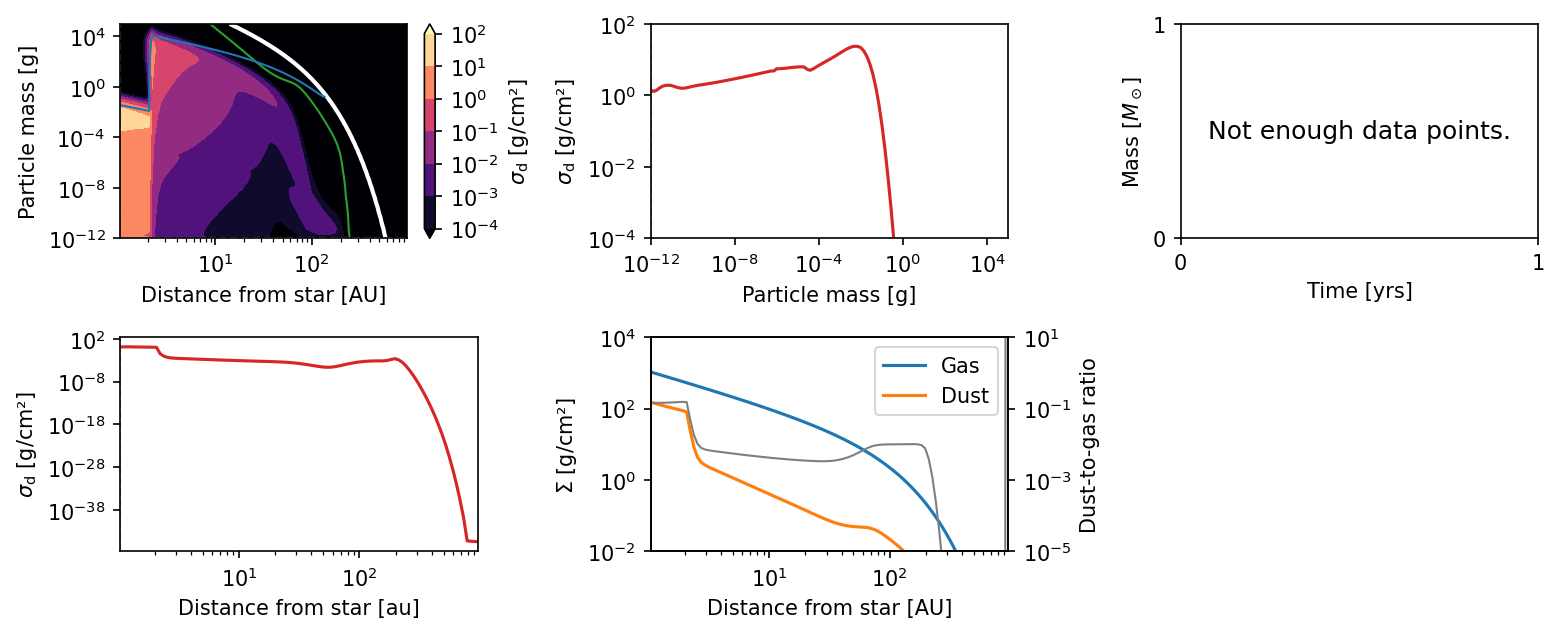

In [13]:
plot.panel(sim)